In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

np.random.seed(42)

In [2]:
##  Data-generating process for the RCT and OBS are implemented in this cell.

def generate_rct_treatment(row):
    return np.random.binomial(1, 0.5)


def generate_obs_treatment(row):
    if row["X1"] == -1:
        return np.random.binomial(1, 0.1)
    else:
        if row["U1"] == -1:
            return np.random.binomial(1, 0.9)
        else:
            return np.random.binomial(1, 0.1)


def generate_outcome(row):
    if row['T'] == 0:
        return np.random.normal() * 0.01
    else:
        if row["X1"] == -1:
            return row["X1"] + np.random.normal() * 0.01
        else:
            return 1 + row["X1"] + row["U1"] + np.random.normal() * 0.01
        

def generate_treatment_and_outcome(df, fn_tr, fn_out):
    df["T"] = df.apply(fn_tr, axis=1)
    df["Y"] = df.apply(fn_out, axis=1)


##  function for generating and logging the predictions & stats related to the fitted outcome models

def log_om_res(df, covs, model):

    if model == "DTR":
        om_T0 = DecisionTreeRegressor().fit(df.query("T==0")[covs], df.query("T==0")["Y"])
        om_T1 = DecisionTreeRegressor().fit(df.query("T==1")[covs], df.query("T==1")["Y"])

    df["hat_Y0"] = om_T0.predict(df[covs])  # log counter-factual outcome predictions for T=0
    df["hat_Y1"] = om_T1.predict(df[covs])  # log counter-factual outcome predictions for T=1

    df["SE_Y0"] = (df.query("T==0")["Y"] - df.query("T==0")["hat_Y0"]) ** 2  # log instance-wise squared-error of the outcome model for T=0
    df["SE_Y1"] = (df.query("T==1")["Y"] - df.query("T==1")["hat_Y1"]) ** 2  # log instance-wise squared-error of the outcome model for T=1


def log_ps_res(df, covs, model):
    if model == "DTC":
        psm = DecisionTreeClassifier().fit(df[covs], df["T"])
        
    df["hat_P(T=1)"] = psm.predict_proba(df[covs])[:,1]
    df["BCELoss_T"] = - df["T"] * np.log(df["hat_P(T=1)"]) - (1 - df["T"]) * np.log(1 - df["hat_P(T=1)"])


def log_sm_res(df, covs, model):
    if model == "DTC":
        sm = DecisionTreeClassifier().fit(df[covs], df["S"])
    df["hat_P(S=1)"] = sm.predict_proba(df[covs])[:,1]


def psi0(row):
    if row["S"] == 1:
        return 0
    else:
        t_ind = row["T"]
        p_s1, p_t1 = row["hat_P(S=1)"], row["hat_P(T=1)"]
        y, mu0, mu1 = row["Y"], row["hat_Y0"], row["hat_Y1"]

        term_1 = mu1 - mu0
        term_2 = t_ind * (y - mu1) / p_t1
        term_3 = (1 - t_ind) * (y - mu0) / (1 - p_t1)

        return (term_1 + term_2 - term_3)/ (1 - p_s1)


def psi1(row):
    if row["S"] == 0:
        return 0
    else:
        t_ind = row["T"]
        p_s1, p_t1 = row["hat_P(S=1)"], row["hat_P(T=1)"]
        y, mu0, mu1 = row["Y"], row["hat_Y0"], row["hat_Y1"]

        term_1 = mu1 - mu0
        term_2 = t_ind * (y - mu1) / p_t1
        term_3 = (1 - t_ind) * (y - mu0) / (1 - p_t1)

        return (term_1 + term_2 - term_3) / p_s1
    

def calc_contrasts(df):
    df["psi0"] = df.apply(psi0, axis=1)
    df["psi1"] = df.apply(psi1, axis=1)
    df["psi"] = df["psi1"] - df["psi0"]

In [3]:
n_covs = 1
n_unmeasured_covs = 1
covs = [f'X{i+1}' for i in range(n_covs)] 
unmeasured_covs = [f'U{i+1}' for i in range(n_unmeasured_covs)] 

n_rct = 1000
n_obs = 10000

X_rct = np.random.choice([-1, 1], size=(n_rct, n_covs))
U_rct = np.random.choice([-1, 1], size=(n_rct, n_unmeasured_covs))

df_rct = pd.DataFrame({**{cov: X_rct[:,i] for i, cov in enumerate(covs)},
                        **{u_cov: U_rct[:,i] for i, u_cov in enumerate(unmeasured_covs)},
                        **{'S': 1}})

X_obs = np.random.choice([-1, 1], size=(n_obs, n_covs))
U_obs = np.random.choice([-1, 1], size=(n_obs, n_unmeasured_covs))

df_obs = pd.DataFrame({**{cov: X_obs[:,i] for i, cov in enumerate(covs)},
                        **{u_cov: U_obs[:,i] for i, u_cov in enumerate(unmeasured_covs)},
                        **{'S': 0}})

In [4]:
obs_covs = covs + unmeasured_covs

generate_treatment_and_outcome(df_rct, generate_rct_treatment, generate_outcome)
log_om_res(df_rct, obs_covs, "DTR")
log_ps_res(df_rct, obs_covs, "DTC")

generate_treatment_and_outcome(df_obs, generate_obs_treatment, generate_outcome)
df_obs["Is_elim"] = df_obs.apply(lambda r: 1 / (1 + np.exp(-r["Y"])) > np.random.uniform(), axis=1).astype(int) 
df_obs = df_obs[df_obs["Is_elim"] == 0].reset_index(drop=True).drop(columns={"Is_elim"})

log_om_res(df_obs, obs_covs, "DTR")
log_ps_res(df_obs, obs_covs, "DTC")

df_merged = pd.concat((df_rct, df_obs))
log_sm_res(df_merged, covs, "DTC")

calc_contrasts(df_merged)

In [7]:
import os
current_dir = os.getcwd()
current_dir += "/research/benchmarking-os/synthetic/toy-notebooks"
df_merged.to_csv(os.path.join(current_dir, "df_merged_selection.csv"), index=False)

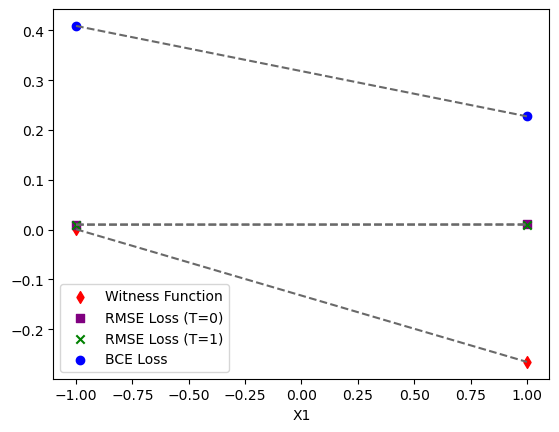

In [5]:
wf = np.zeros(2)
wf[0] = df_merged.query("X1 == -1")["psi"].dropna().mean()
wf[1] = df_merged.query("X1 == 1")["psi"].dropna().mean()

bceloss = np.zeros(2)
bceloss[0] = df_merged.query("S==0 & X1==-1")["BCELoss_T"].dropna().mean()
bceloss[1] = df_merged.query("S==0 & X1==1")["BCELoss_T"].dropna().mean()

mseloss_t0 = np.zeros(2)
mseloss_t0[0] = df_merged.query("S==0 & X1==-1 & T==0")["SE_Y0"].dropna().mean()
mseloss_t0[1] = df_merged.query("S==0 & X1==1 & T==0")["SE_Y0"].dropna().mean()

mseloss_t1 = np.zeros(2)
mseloss_t1[0] = df_merged.query("S==0 & X1==-1 & T==1")["SE_Y1"].dropna().mean()
mseloss_t1[1] = df_merged.query("S==0 & X1==1 & T==1")["SE_Y1"].dropna().mean()

plt.figure()

plt.plot([-1,1], wf, ls='--', color="dimgray")
plt.scatter([-1,1], wf, marker='d', color='r',  label="Witness Function",)

plt.plot([-1,1], np.sqrt(mseloss_t0), ls='--', color="dimgray")
plt.scatter([-1,1], np.sqrt(mseloss_t0), marker='s', color='purple', label="RMSE Loss (T=0)")

plt.plot([-1,1], np.sqrt(mseloss_t1), ls='--', color="dimgray")
plt.scatter([-1,1], np.sqrt(mseloss_t1), marker='x', color='g', label="RMSE Loss (T=1)")

plt.plot([-1,1], bceloss, ls='--', color="dimgray")
plt.scatter([-1,1], bceloss, marker='o', color='b', label="BCE Loss")

plt.xlabel("X1")
plt.legend()
plt.show()